In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('gurgaon_properties_post_feature_selection.csv')

In [3]:
df.sample(5)

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,price
2654,0.0,17.0,2,2,2.0,3.0,1430.0,0,0,0,2.0,2.0,1.75
1576,0.0,25.0,3,4,3.0,3.0,2500.0,1,0,2,2.0,2.0,4.78
256,0.0,9.0,3,4,4.0,3.0,1345.0,1,0,0,0.0,2.0,1.05
2641,0.0,99.0,3,2,2.0,4.0,1141.0,0,0,0,1.0,2.0,0.61
3513,0.0,83.0,3,3,2.0,3.0,1212.0,0,0,1,0.0,1.0,1.25


In [6]:
df.shape

(3670, 13)

<Axes: xlabel='price', ylabel='Count'>

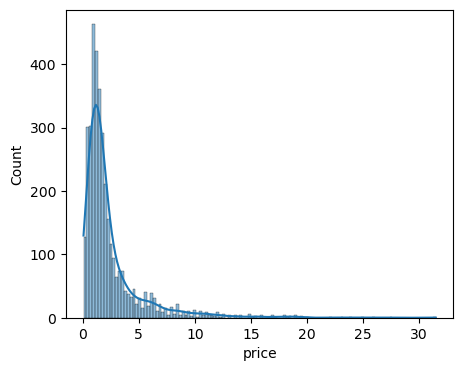

In [7]:
plt.figure(figsize=(5,4))
sns.histplot(df['price'],kde=True)

In [8]:
X = df.drop(columns='price')
y = df['price']

In [9]:
y_transformed = np.log1p(y)

<Axes: xlabel='price', ylabel='Count'>

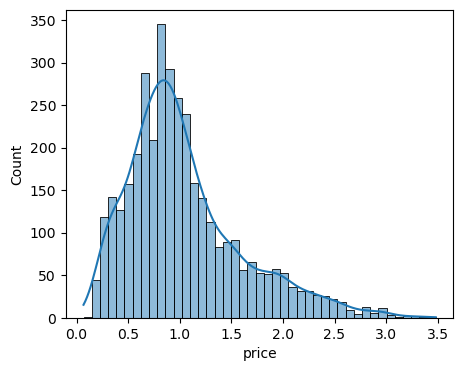

In [10]:
plt.figure(figsize=(5,4))
sns.histplot(y_transformed,kde=True)

In [11]:
from sklearn.model_selection import KFold , cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error

In [12]:
columns = ['sector', 'balcony', 'agePossession', 'furnishing_type', 'luxury_category', 'floor_category']

In [13]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), ['property_type', 'bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']),
        ('cat', OneHotEncoder(drop='first'), columns)
    ],
    remainder = 'passthrough'
)

In [14]:
pipeline = Pipeline([
    ('preprocessor' , preprocessor),
    ('regressor' , SVR(kernel='rbf'))
])

In [15]:
kf = KFold(n_splits=10, shuffle=True, random_state = 42)
scores = cross_val_score(pipeline, X, y_transformed, cv=kf, scoring = 'r2')

In [16]:
scores.mean()

np.float64(0.8833161409234446)

In [17]:
scores.std()

np.float64(0.025446287059908576)

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)

In [19]:
pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
y_pred = pipeline.predict(X_test)

In [21]:
y_pred1 = np.expm1(y_pred)

In [22]:
y_test.shape

(734,)

In [23]:
y_test.head()

179     1.704748
2679    0.405465
3542    0.845868
1061    2.091864
1091    0.832909
Name: price, dtype: float64

In [24]:
mean_absolute_error(np.expm1(y_test),y_pred1)

0.6092824201249907